# Stress-response gene expression
There are numerous papers that pull out "stress-response" genes that are markers of stress. FC is on a [paper](https://www-sciencedirect-com.umasslowell.idm.oclc.org/science/article/pii/S0147651326009929?fr=RR-2&ref=pdf_download&rr=a43415c0ade2896f) that included some. Here, I'm going to look at the relative expression of these stress response genes in phase 1 and 2 oysters.

## 0. load libraries

In [20]:
library(tidyverse)
library(RColorBrewer)
library(cowplot) # adding plots together
library(rtracklayer) # reading gtf file

## 1. read csvs

### phase 1 vst

In [12]:
p1.vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res/prefilter_deseq/p1_vst.csv') %>%
rename('Gene' = X) %>%
pivot_longer(
    cols = -Gene,
    names_to = 'Sample',
    values_to = 'vst_expr'
    ) %>%
mutate(oys_phase = 'Phase1')

head(p1.vst)

Gene,Sample,vst_expr,oys_phase
<chr>,<chr>,<dbl>,<chr>
LOC144621260,B1_Nu_O03,11.21797,Phase1
LOC144621260,B2_Nu_O12,11.93477,Phase1
LOC144621260,B4_Nu_O32,11.22476,Phase1
LOC144621260,B5_Nu_O36,11.38600,Phase1
LOC144621260,B6_Nu_O47,11.49149,Phase1
LOC144621260,C1_Nu_W01,11.33041,Phase1


### phase 2 vst

In [13]:
p2.vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res/prefilter_deseq/vst_filtered.csv') %>%
rename('Gene' = X) %>%
pivot_longer(
    cols = -Gene,
    names_to = 'Sample',
    values_to = 'vst_expr'
    ) %>%
mutate(oys_phase = 'Phase2')

head(p2.vst)

Gene,Sample,vst_expr,oys_phase
<chr>,<chr>,<dbl>,<chr>
LOC144621260,B1_B1_O01,11.62347,Phase2
LOC144621260,B1_W5_O50,11.42347,Phase2
LOC144621260,B2_B5_O51,11.40884,Phase2
LOC144621260,B2_C4_O40,11.27515,Phase2
LOC144621260,B3_B4_O41,11.00057,Phase2
LOC144621260,B3_C3_O30,10.98404,Phase2


#### combine expression dfs

In [15]:
vst.df <- rbind(p1.vst, p2.vst)

head(vst.df)
tail(vst.df)

Gene,Sample,vst_expr,oys_phase
<chr>,<chr>,<dbl>,<chr>
LOC144621260,B1_Nu_O03,11.21797,Phase1
LOC144621260,B2_Nu_O12,11.93477,Phase1
LOC144621260,B4_Nu_O32,11.22476,Phase1
LOC144621260,B5_Nu_O36,11.38600,Phase1
LOC144621260,B6_Nu_O47,11.49149,Phase1
LOC144621260,C1_Nu_W01,11.33041,Phase1


Gene,Sample,vst_expr,oys_phase
<chr>,<chr>,<dbl>,<chr>
LOC144621888,W5_W2_G22,9.814569,Phase2
LOC144621888,W6_B3_G35,9.653304,Phase2
LOC144621888,W6_B4_G48,9.047223,Phase2
LOC144621888,W6_H6_G71,8.695508,Phase2
LOC144621888,W6_W3_G36,8.846505,Phase2
LOC144621888,W6_W4_G48,8.817083,Phase2


### meta data

In [10]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv')
head(meta)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA


#### add meta data to vst df

In [17]:
vst.meta <- merge(vst.df, meta, by = 'Sample')
head(vst.meta)

,Sample,Gene,vst_expr,oys_phase,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,LOC144621260,11.623469,Phase2,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_B1_O01,LOC111116247,8.853079,Phase2,both,warm,hypoxic,1,both,warm,hypoxic,1
3,B1_B1_O01,LOC144617820,8.483578,Phase2,both,warm,hypoxic,1,both,warm,hypoxic,1
4,B1_B1_O01,LOC144626966,10.763678,Phase2,both,warm,hypoxic,1,both,warm,hypoxic,1
5,B1_B1_O01,LOC111117188,11.698011,Phase2,both,warm,hypoxic,1,both,warm,hypoxic,1
6,B1_B1_O01,LOC111109973,10.602855,Phase2,both,warm,hypoxic,1,both,warm,hypoxic,1


### gene annotations

In [37]:
gtf <- as.data.frame(import('/project/pi_sarah_gignouxwolfsohn_uml_edu/Reference_genomes/Cvirginica_genome/new_cvir_genome/GCF_053477285.1_ASM5347728v1_genomic.gtf')) %>%
select(gene_id, description)
head(gtf)

,gene_id,description
,<chr>,<chr>
1,LOC144621260,protein O-mannosyl-transferase TMTC2-like
2,LOC144621260,NA
3,LOC144621260,NA
4,LOC144621260,NA
5,LOC144621260,NA
6,LOC144621260,NA


## 2. pull out stress response genes

stress-response genes in [this paper](https://www-sciencedirect-com.umasslowell.idm.oclc.org/science/article/pii/S0147651326009929?fr=RR-2&ref=pdf_download&rr=a43415c0ade2896f):
- **mapk14** (mitogen-activated protein kinase 14): "encodes a signaling protein involved in regulating cellular growth and proliferation"
- **hsp70** (heat shock protein 70): "functions as a mo-lecular chaperone involved in protein stabilization and cellular ho-meostasis and is commonly induced by stressors such as heat, oxidative stress, and toxicant exposure"
- **sod1** (superoxide dismutase 1): "encodes an antiox-idant enzyme that limits cellular damage from reactive oxygen species"
- **gst** (glutathione S-transferase): "comprises detoxification en-zymes that promote the conjugation of glutathione to electrophilic and hydrophobic compounds, facilitating their metabolism and elimination"

#### mapk14
the paper above chose this accession: XM_022444663 which maps to [this gene](https://www.ncbi.nlm.nih.gov/nuccore/XM_022444663.1?report=genbank) that is now a supressed record

In [26]:
gtf %>% filter(str_detect(description, "mitogen-activated protein kinase 14"))

gene_id,description
<chr>,<chr>
LOC111107163,mitogen-activated protein kinase 14A-like


looks like mapk14 is [LOC111107163](https://www.ncbi.nlm.nih.gov/gene/?term=LOC111107163)

In [42]:
mapk14 <- gtf %>% filter(gene_id == 'LOC111107163') %>% mutate(name = 'mapk14')

#### hsp70
the paper above chose this accession: AJ271444

In [28]:
gtf %>% filter(str_detect(description, "heat shock protein 70"))

gene_id,description
<chr>,<chr>
LOC111108251,heat shock protein 70 B2-like
LOC111119512,heat shock protein 70 B2
LOC111119513,heat shock protein 70 B2-like
LOC111121335,heat shock protein 70 B2-like
LOC111120887,heat shock protein 70 B2-like


hmmmm seems like be a couple of different choises for hsp70 - will go back to that paper and see which one they chose - I'm guessing LOC111119512 since it's the only one that isn't following by "-like" in it's name

the paper above chose [LOC111119512](https://www.ncbi.nlm.nih.gov/gene/?term=AJ271444)

In [43]:
hsp70 <- gtf %>% filter(gene_id == 'LOC111119512') %>% mutate(name = 'hsp70')

#### sod1
the paper above chose this accession: XM_022452581

In [31]:
gtf %>% filter(str_detect(description, "superoxide dismutase"))

gene_id,description
<chr>,<chr>
LOC111102390,"superoxide dismutase [Mn], mitochondrial-like"
LOC111129894,copper chaperone for superoxide dismutase-like
LOC111111888,superoxide dismutase [Cu-Zn]-like
LOC111113328,superoxide dismutase [Cu-Zn]-like


again looks like there's two options: LOC111111888 or LOC111113328

the paper above chose [LOC111114294](https://www.ncbi.nlm.nih.gov/gene/?term=XM_022452581) (which is an uncharacterized gene)

In [44]:
sod1 <- gtf %>% filter(gene_id == 'LOC111114294') %>% mutate(name = 'sod1')

#### gst
according to the above paper, they chose this accession: XM_022461225

In [33]:
gtf %>% filter(str_detect(description, "glutathione S-transferase-like"))

gene_id,description
<chr>,<chr>
LOC111120486,glutathione S-transferase-like
LOC111122121,glutathione S-transferase-like
LOC111134208,glutathione S-transferase-like
LOC111138098,glutathione S-transferase-like


[LOC111120486](https://www.ncbi.nlm.nih.gov/gene/?term=XM_022461225)

In [45]:
gst <- gtf %>% filter(gene_id == 'LOC111120486') %>% mutate(name = 'gst')

### make df of stress genes

In [54]:
stress_genes <- rbind(mapk14, hsp70, sod1, gst) %>% 
na.omit() %>%
rename(gene_id = 'Gene')

stress_genes

,Gene,description,name
,<chr>,<chr>,<chr>
1,LOC111107163,mitogen-activated protein kinase 14A-like,mapk14
56,LOC111119512,heat shock protein 70 B2,hsp70
62,LOC111114294,uncharacterized LOC111114294,sod1
90,LOC111120486,glutathione S-transferase-like,gst


### pull expression of stress genes

In [56]:
stress.vst <- vst.meta[vst.meta$Gene %in% stress_genes$Gene,]

stress.vst <- merge(stress.vst, stress_genes, by = 'Gene')

dim(stress.vst)
head(stress.vst)

[1] 460  14

,Gene,Sample,vst_expr,oys_phase,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,description,name
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>
1,LOC111107163,H3_Nu_B18,12.13416,Phase1,hypoxic,ambient,hypoxic,3,NA,NA,NA,NA,mitogen-activated protein kinase 14A-like,mapk14
2,LOC111107163,C5_C3_W33,12.52774,Phase2,control,ambient,normoxic,5,control,ambient,normoxic,3,mitogen-activated protein kinase 14A-like,mapk14
3,LOC111107163,C1_H6_W62,12.67030,Phase2,control,ambient,normoxic,1,hypoxic,ambient,hypoxic,6,mitogen-activated protein kinase 14A-like,mapk14
4,LOC111107163,H4_H2_B19,12.28393,Phase2,hypoxic,ambient,hypoxic,4,hypoxic,ambient,hypoxic,2,mitogen-activated protein kinase 14A-like,mapk14
5,LOC111107163,W4_H1_G08,12.19610,Phase2,warm,warm,normoxic,4,hypoxic,ambient,hypoxic,1,mitogen-activated protein kinase 14A-like,mapk14
6,LOC111107163,B3_B4_O41,12.40369,Phase2,both,warm,hypoxic,3,both,warm,hypoxic,4,mitogen-activated protein kinase 14A-like,mapk14


## 3. plot expression

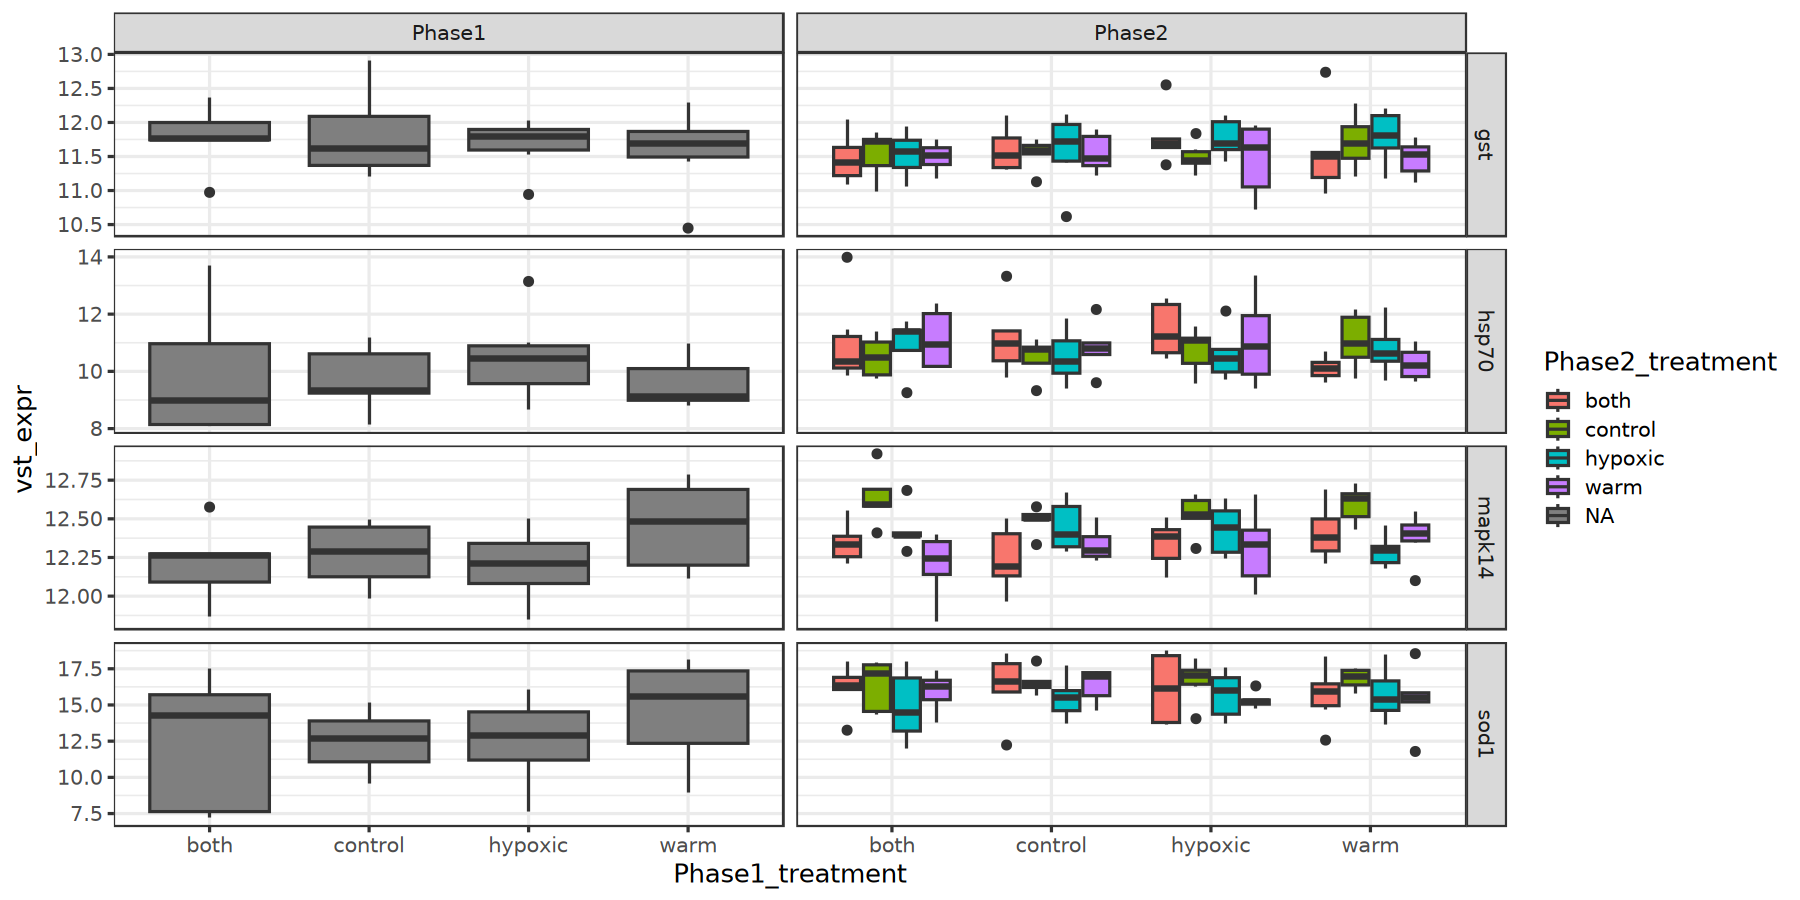

In [61]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

ggplot(stress.vst, aes(x = Phase1_treatment, y = vst_expr, fill = Phase2_treatment)) +
geom_boxplot() +
facet_grid(name ~ oys_phase, scales = 'free') +
theme_bw(base_size = 15)

### phase 2 oysters

In [67]:
# set factor levels
# phase 1
stress.vst$Phase1_treatment <- factor(stress.vst$Phase1_treatment, levels = c('control', 'hypoxic', 'warm', 'both'))
# phase 2
stress.vst$Phase2_treatment <- factor(stress.vst$Phase2_treatment, levels = c('control', 'hypoxic', 'warm', 'both'))

#### only phase 2 treatment:

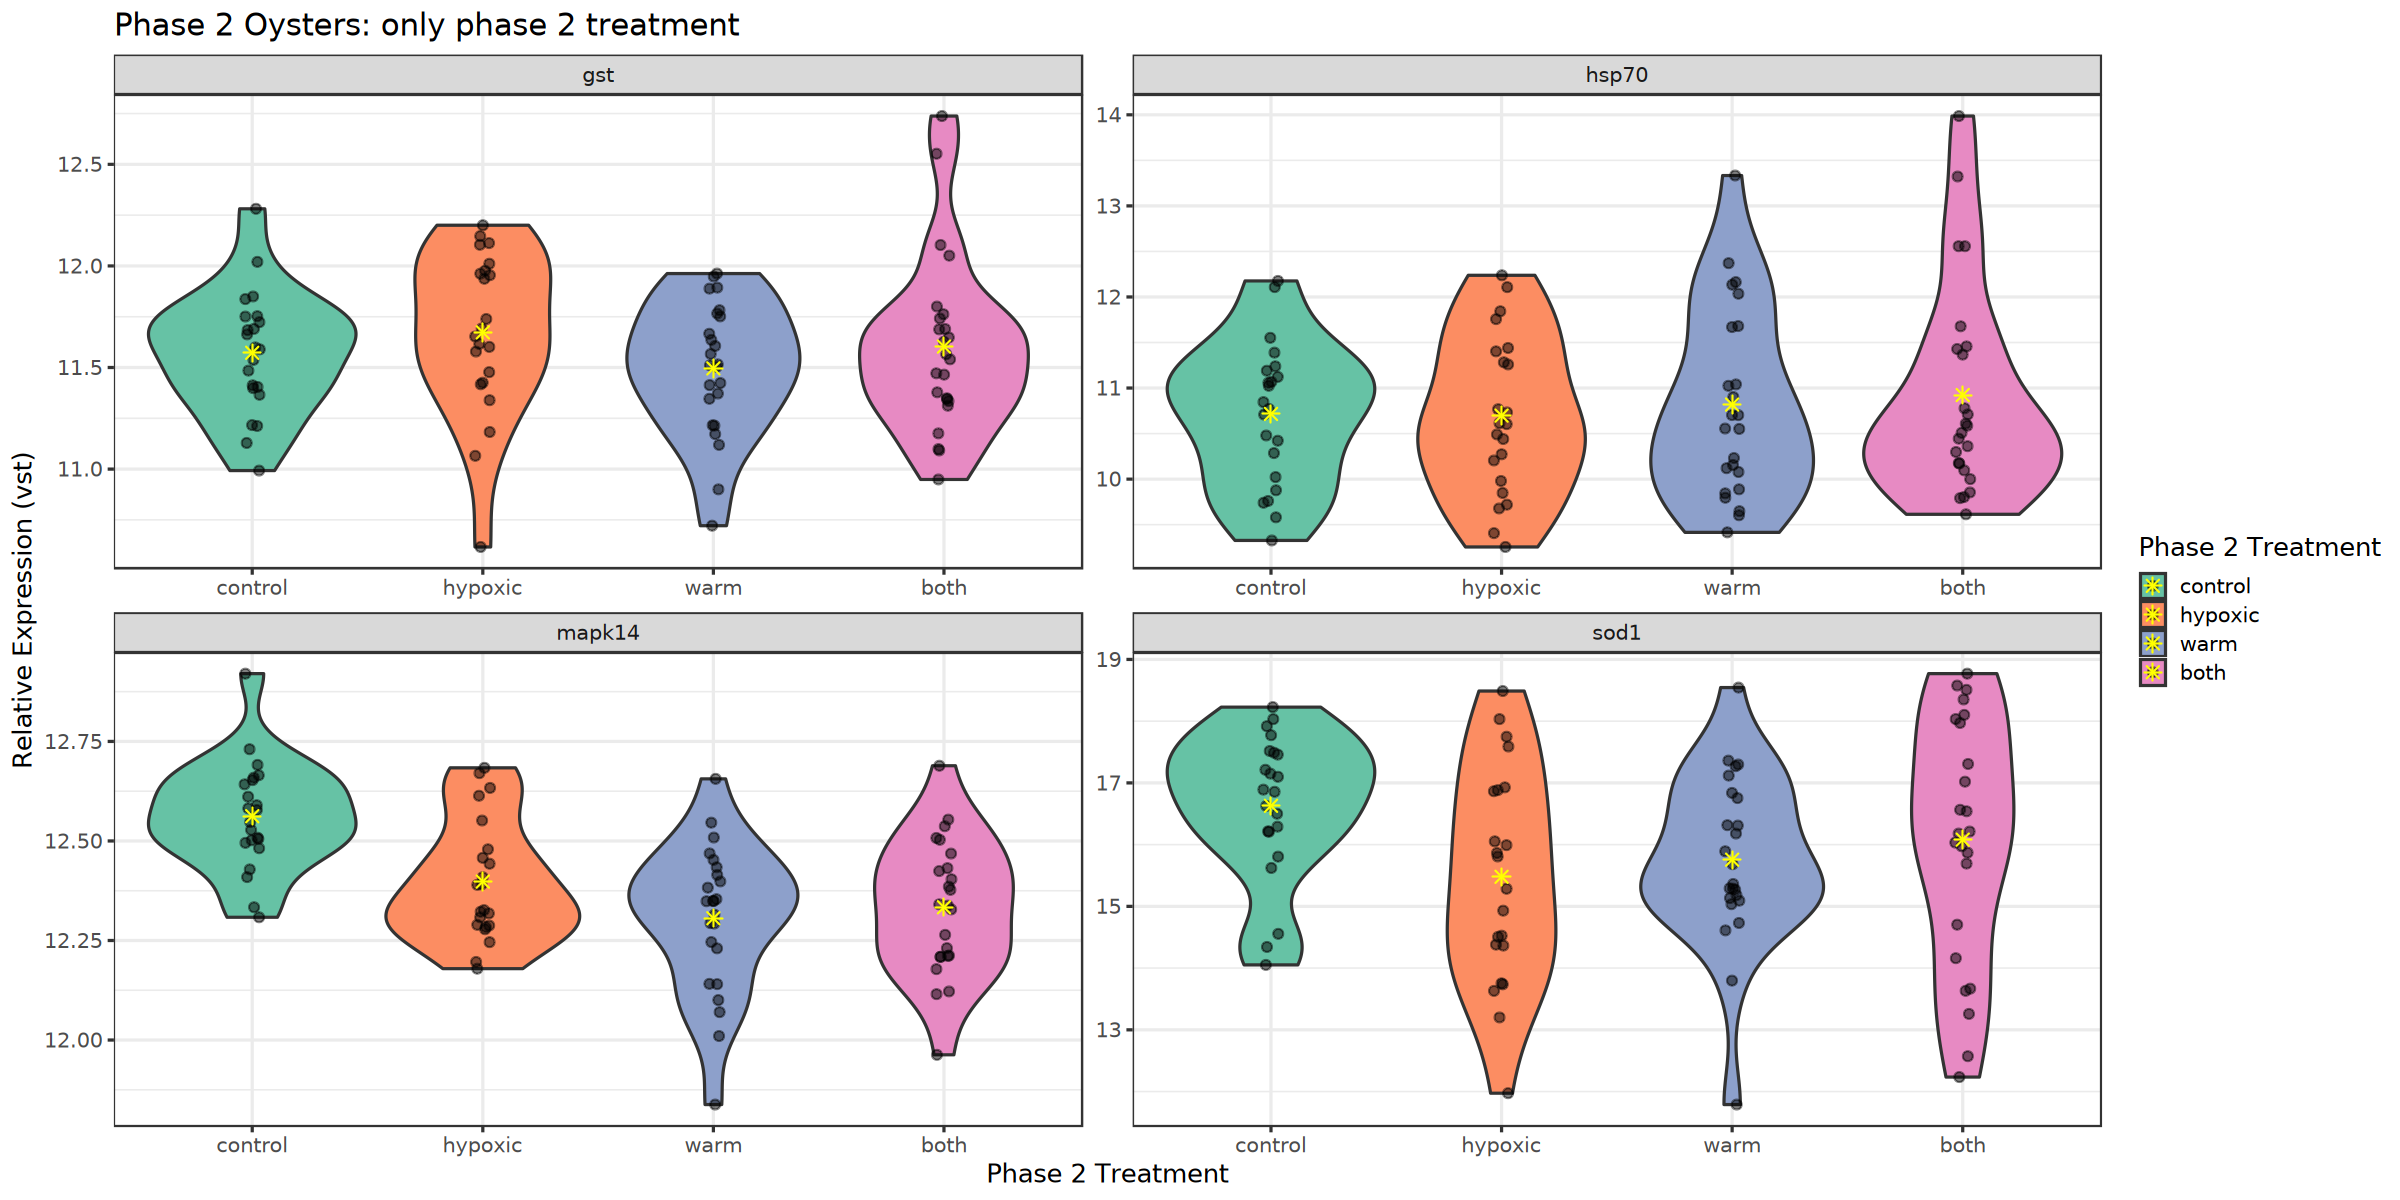

In [80]:
options(repr.plot.width = 20, repr.plot.height = 10)

ggplot(stress.vst %>% filter(oys_phase == 'Phase2'), aes(x = Phase2_treatment, y = vst_expr, fill = Phase2_treatment)) +
geom_violin(
    position = position_dodge(width = 0.75)
  ) +
  geom_point(
    position = position_jitterdodge(
      jitter.width = 0.1,
      dodge.width = 0.75
    ),
    alpha = 0.5
  ) +
stat_summary(
    position = position_dodge(width = 0.75),
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
facet_wrap(~ name, scales = 'free') +
scale_fill_brewer(palette = 'Set2') +
theme_bw(base_size = 15) +
labs(x = 'Phase 2 Treatment',
     y = 'Relative Expression (vst)',
     fill = 'Phase 2 Treatment',
    title = 'Phase 2 Oysters: only phase 2 treatment')

**observations**:
- stressed oysters (warm, hypoxic, both) in phase 2 have decreased expression of mapk14 compared to those that are in control conditions (regardless of the treatment they experienced in phase 1)

#### only phase 1 treatment:

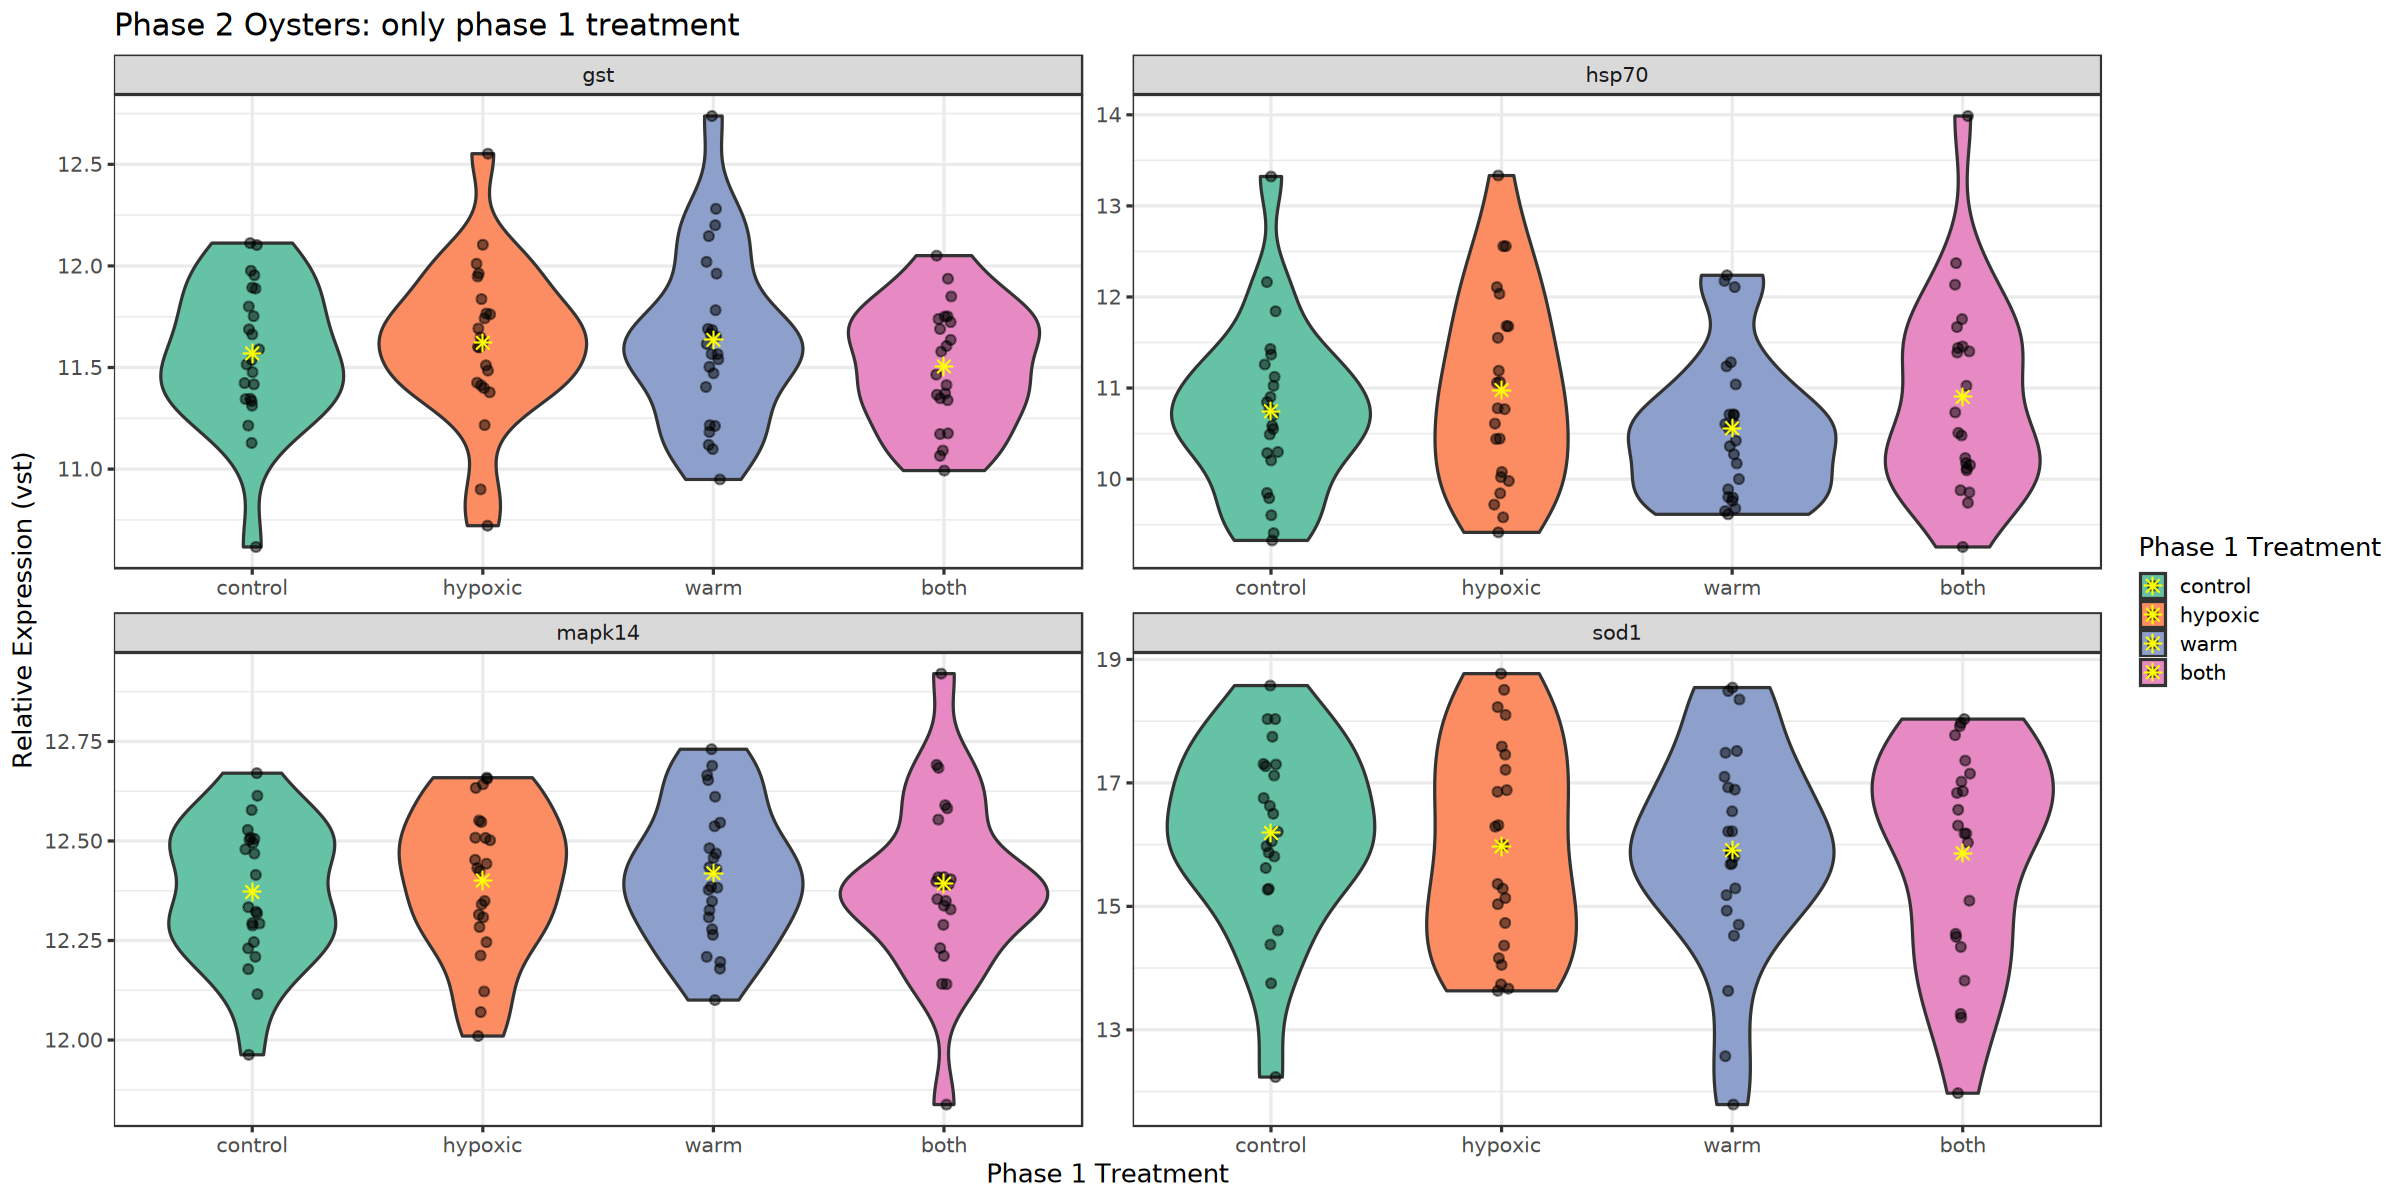

In [81]:
options(repr.plot.width = 20, repr.plot.height = 10)

ggplot(stress.vst %>% filter(oys_phase == 'Phase2'), aes(x = Phase1_treatment, y = vst_expr, fill = Phase1_treatment)) +
geom_violin(
    position = position_dodge(width = 0.75)
  ) +
  geom_point(
    position = position_jitterdodge(
      jitter.width = 0.1,
      dodge.width = 0.75
    ),
    alpha = 0.5
  ) +
stat_summary(
    position = position_dodge(width = 0.75),
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
facet_wrap(~ name, scales = 'free') +
scale_fill_brewer(palette = 'Set2') +
theme_bw(base_size = 15) +
labs(x = 'Phase 1 Treatment',
     y = 'Relative Expression (vst)',
     fill = 'Phase 1 Treatment',
    title = 'Phase 2 Oysters: only phase 1 treatment')

**observations**:
- doesn't appear to be any strong patterns of expression when considering only the phase 1 treatment (and ignoring phase 2)
- this is unsurprising - we expect gene expression to be mostly influenced by the most recent exposure

#### phase 1 and 2 treatments:

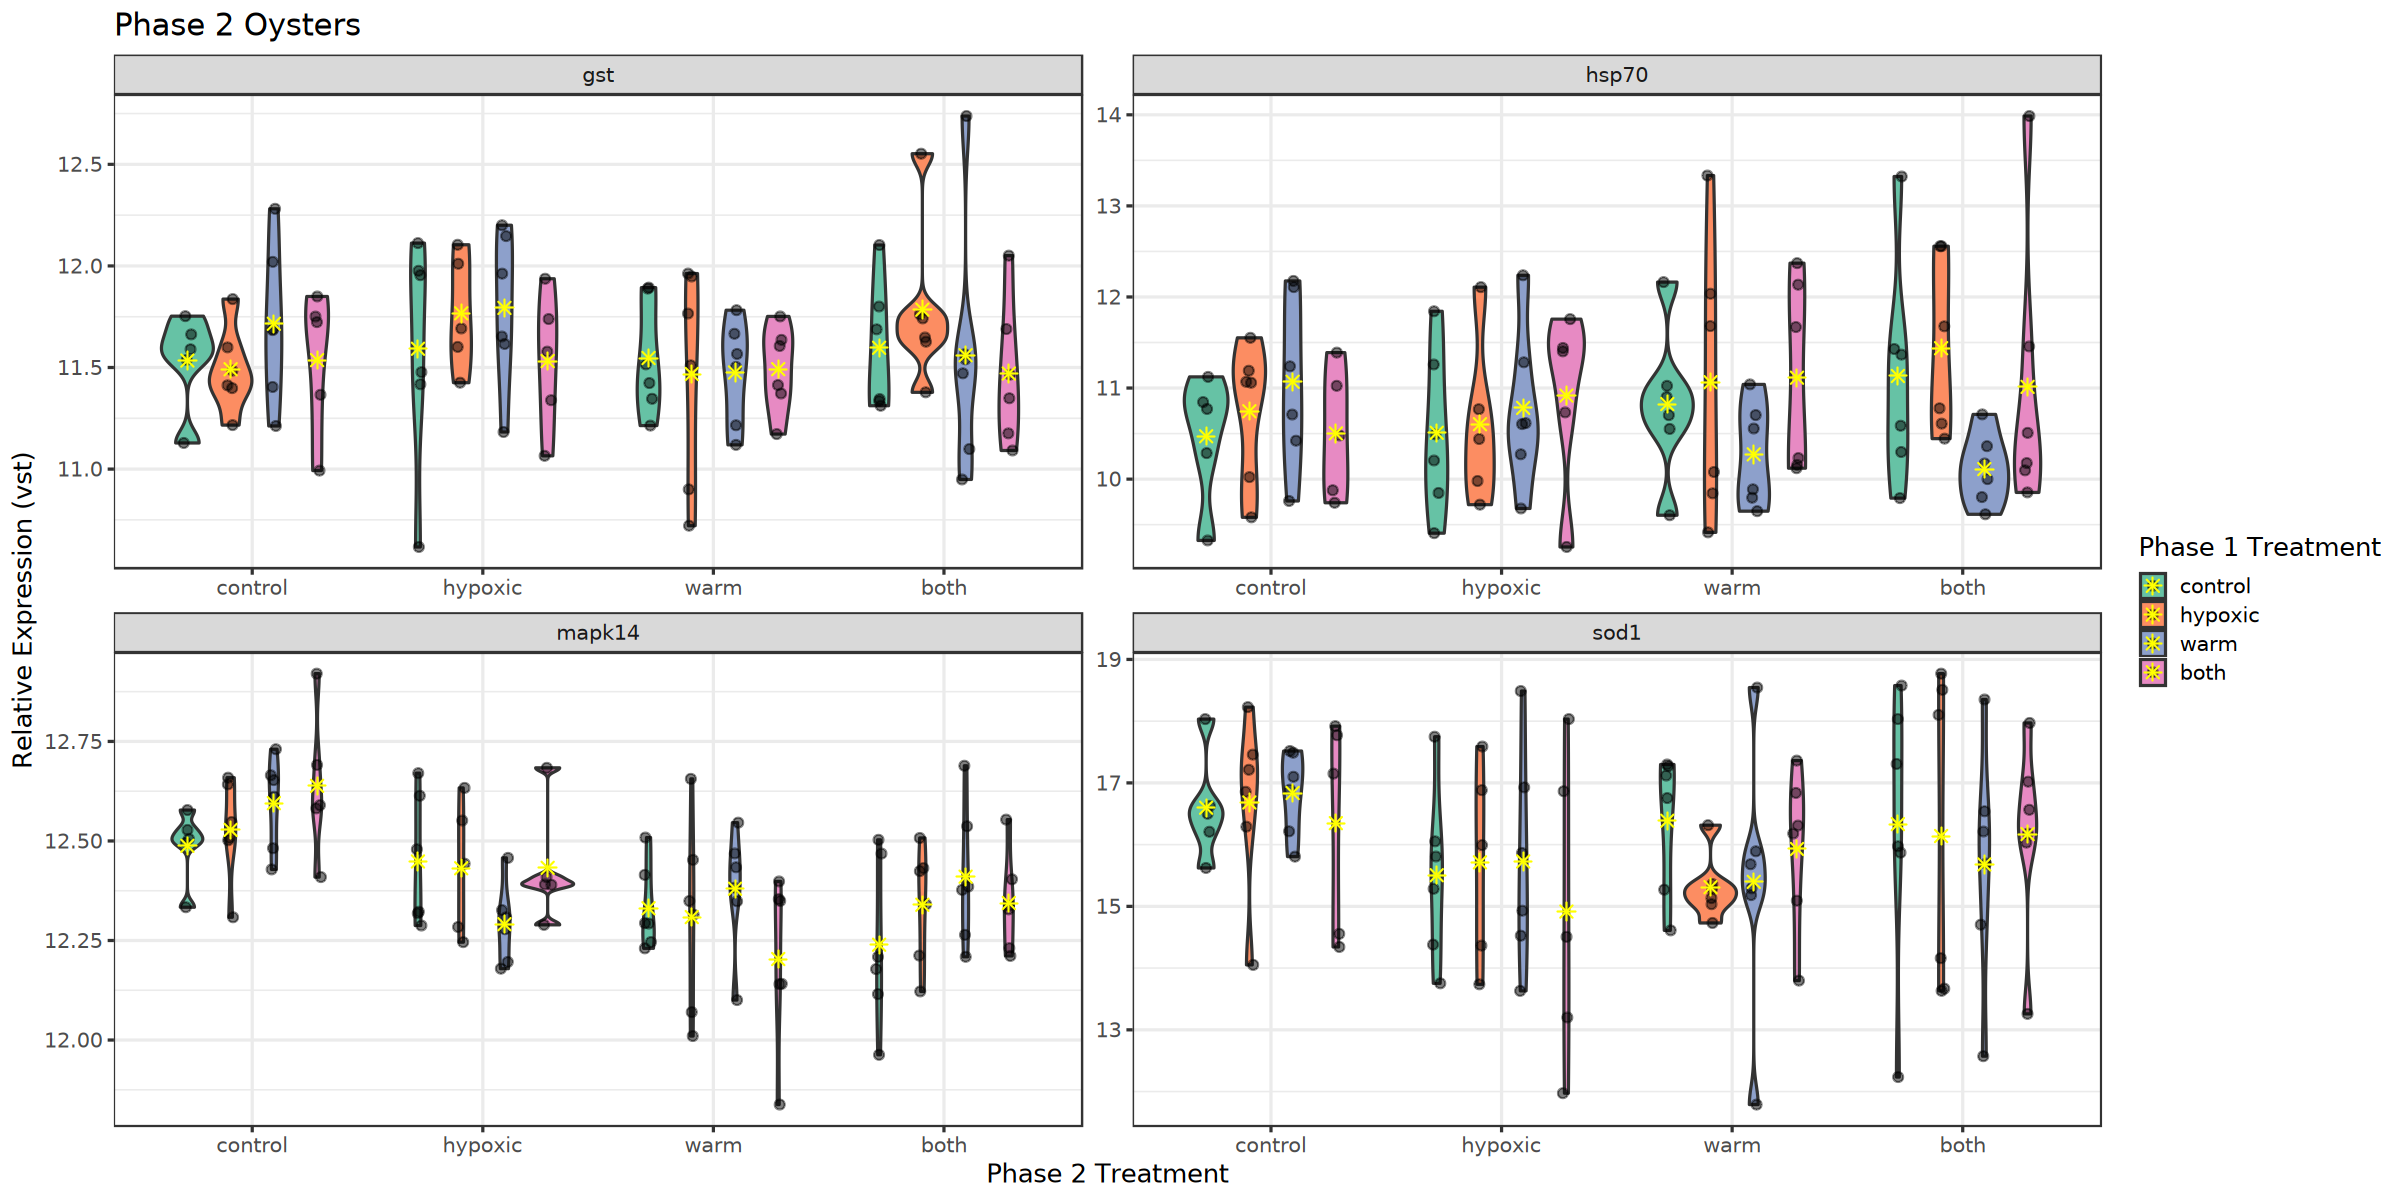

In [79]:
options(repr.plot.width = 20, repr.plot.height = 10)

ggplot(stress.vst %>% filter(oys_phase == 'Phase2'), aes(x = Phase2_treatment, y = vst_expr, fill = Phase1_treatment)) +
geom_violin(
    position = position_dodge(width = 0.75)
  ) +
  geom_point(
    position = position_jitterdodge(
      jitter.width = 0.1,
      dodge.width = 0.75
    ),
    alpha = 0.5
  ) +
stat_summary(
    position = position_dodge(width = 0.75),
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
facet_wrap(~ name, scales = 'free') +
scale_fill_brewer(palette = 'Set2') +
theme_bw(base_size = 15) +
labs(x = 'Phase 2 Treatment',
     y = 'Relative Expression (vst)',
     fill = 'Phase 1 Treatment',
    title = 'Phase 2 Oysters')

as a reminder:
>from [Salcedo et al., 2026](https://www-sciencedirect-com.umasslowell.idm.oclc.org/science/article/pii/S0147651326009929?fr=RR-2&ref=pdf_download&rr=a43415c0ade2896f)
- mapk14 (mitogen-activated protein kinase 14): "encodes a signaling protein involved in regulating cellular growth and proliferation"
- hsp70 (heat shock protein 70): "functions as a molecular chaperone involved in protein stabilization and cellular homeostasis and is commonly induced by stressors such as heat, oxidative stress, and toxicant exposure"
- sod1 (superoxide dismutase 1): "encodes an antioxidant enzyme that limits cellular damage from reactive oxygen species"
- gst (glutathione S-transferase): "comprises detoxification enzymes that promote the conjugation of glutathione to electrophilic and hydrophobic compounds, facilitating their metabolism and elimination"

**observations**:
- **gst**: higher expression in WC compared to CC, HC, and BC; higher expression in HB compared to CB, WB, and BB
- **hsp70**: phase 1 warm oysters have lower expression when they experience warm or both later in life
- **mapk14**: phase 1 warm oysters tend to have higher expression compared to other oysters that experienced the same phase 2 treatments
- **sod1**: seems like expression is more variable between replicates - less variable for HW though

### phase 1 oysters

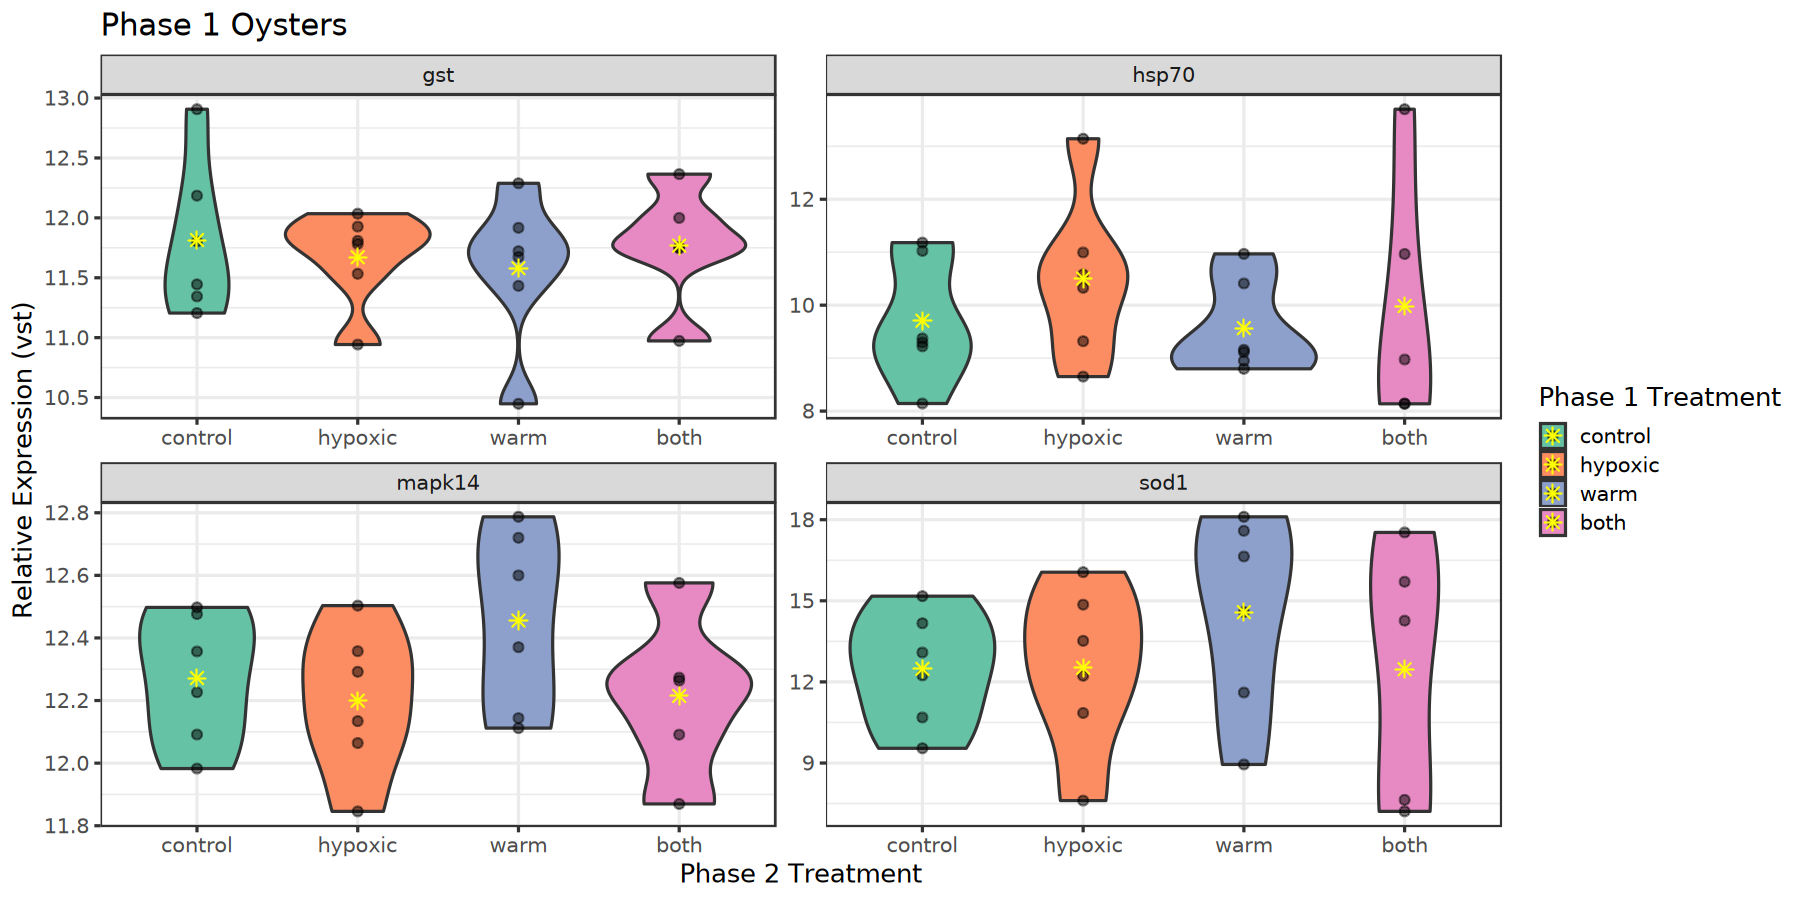

In [75]:
options(repr.plot.width = 15, repr.plot.height = 7.5)

ggplot(stress.vst %>% filter(oys_phase == 'Phase1'), aes(x = Phase1_treatment, y = vst_expr, fill = Phase1_treatment)) +
geom_violin() +
geom_point(alpha = 0.5) +
stat_summary(
    position = position_dodge(width = 0.75),
    fun = "mean", 
    geom = "point", 
    shape = 8,      # asterick shape
    size = 3,        # Size of the point
    color = "yellow"  # Outline color
  ) +
facet_wrap(~ name, scales = 'free') +
scale_fill_brewer(palette = 'Set2') +
theme_bw(base_size = 15) +
labs(x = 'Phase 2 Treatment',
     y = 'Relative Expression (vst)',
     fill = 'Phase 1 Treatment',
    title = 'Phase 1 Oysters')

**observations**:
- mapk14 expression is higher in oysters that experienced warm stress
    - mapk14 = cell growth and proliferation
    - we do see increased shell growth in the warm treatment - so this gene could potentially be responsible (should check if that gene is in one of the growth correlated modules)
- all other genes seem to have quite a bit of overlap/no obvious differences between treatments 